
CLASSIFICATION REPORT
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.90      0.95        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       0.95      1.00      0.98        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
    

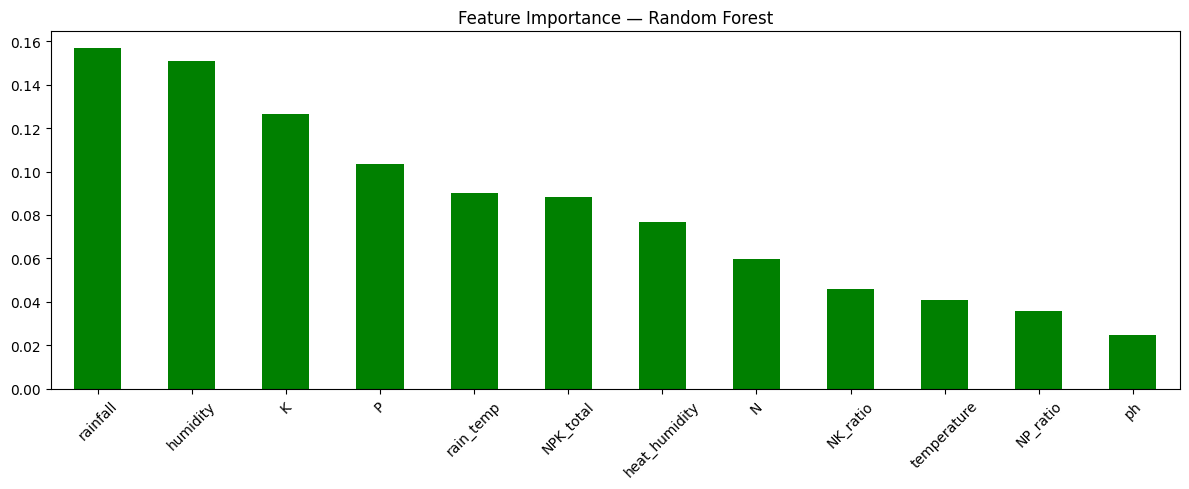


 Models and preprocessors saved successfully!

 Prediction function ready for deployment


In [1]:
# =============================================================
# 0. IMPORTS
# =============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

# =============================================================
# 1. CHARGEMENT DES DONNÉES
# =============================================================
df = pd.read_csv("crop_recommendation.csv")

# =============================================================
# 2. NETTOYAGE RAPIDE
# =============================================================
df = df.drop_duplicates()

# Imputation simple (si besoin)
for col in df.select_dtypes(include=[np.number]).columns:
    df[col] = df[col].fillna(df[col].median())

# =============================================================
# 3. FEATURE ENGINEERING
# =============================================================
df_fe = df.copy()

df_fe["NPK_total"] = df_fe["N"] + df_fe["P"] + df_fe["K"]
df_fe["NP_ratio"] = df_fe["N"] / (df_fe["P"] + 1e-6)
df_fe["NK_ratio"] = df_fe["N"] / (df_fe["K"] + 1e-6)
df_fe["heat_humidity"] = df_fe["temperature"] * df_fe["humidity"] / 100
df_fe["rain_temp"] = df_fe["rainfall"] * df_fe["temperature"]

# =============================================================
# 4. SPLIT FEATURES / TARGET
# =============================================================
X = df_fe.drop("label", axis=1)
y = df_fe["label"]

# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# =============================================================
# 5. TRAIN / TEST SPLIT
# =============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# =============================================================
# 6. SCALING
# =============================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =============================================================
# 7. TRAIN MODEL — RANDOM FOREST
# =============================================================
best_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

best_rf.fit(X_train_scaled, y_train)

# =============================================================
# 8. EVALUATION
# =============================================================
y_pred = best_rf.predict(X_test_scaled)

print("\n=================================================")
print("CLASSIFICATION REPORT")
print("=================================================")
print(classification_report(y_test, y_pred, target_names=le.classes_))

print("\nAccuracy:", accuracy_score(y_test, y_pred))

# =============================================================
# 9. FEATURE IMPORTANCE
# =============================================================
feat_imp = pd.Series(best_rf.feature_importances_, index=X.columns)
feat_imp_sorted = feat_imp.sort_values(ascending=False)

plt.figure(figsize=(12,5))
feat_imp_sorted.plot(kind="bar", color="green")
plt.title("Feature Importance — Random Forest")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =============================================================
# 10. SAUVEGARDE DES ARTEFACTS
# =============================================================
import os
os.makedirs("artifacts", exist_ok=True)

joblib.dump(best_rf, "artifacts/cls_best_model.pkl")
joblib.dump(scaler, "artifacts/cls_scaler.pkl")
joblib.dump(le, "artifacts/cls_label_encoder.pkl")
joblib.dump(list(X.columns), "artifacts/cls_feature_columns.pkl")

print("\n Models and preprocessors saved successfully!")

# =============================================================
# 11. FONCTION DE PRÉDICTION (POUR L'INTERFACE)
# =============================================================
def predict_crop(N, P, K, temperature, humidity, ph, rainfall):

    _model = joblib.load("artifacts/cls_best_model.pkl")
    _scaler = joblib.load("artifacts/cls_scaler.pkl")
    _le = joblib.load("artifacts/cls_label_encoder.pkl")
    _cols = joblib.load("artifacts/cls_feature_columns.pkl")

    df_row = pd.DataFrame([{
        "N": N,
        "P": P,
        "K": K,
        "temperature": temperature,
        "humidity": humidity,
        "ph": ph,
        "rainfall": rainfall
    }])

    # Feature engineering (IMPORTANT: SAME AS TRAINING)
    df_row["NPK_total"] = df_row["N"] + df_row["P"] + df_row["K"]
    df_row["NP_ratio"] = df_row["N"] / (df_row["P"] + 1e-6)
    df_row["NK_ratio"] = df_row["N"] / (df_row["K"] + 1e-6)
    df_row["heat_humidity"] = df_row["temperature"] * df_row["humidity"] / 100
    df_row["rain_temp"] = df_row["rainfall"] * df_row["temperature"]

    df_row = df_row[_cols]

    X_scaled = _scaler.transform(df_row)
    pred = _model.predict(X_scaled)[0]

    return _le.inverse_transform([pred])[0]


print("\n Prediction function ready for deployment")

In [1]:
import joblib
import pandas as pd

# Load saved artifacts
model = joblib.load("artifacts/cls_best_model.pkl")
scaler = joblib.load("artifacts/cls_scaler.pkl")
le = joblib.load("artifacts/cls_label_encoder.pkl")
cols = joblib.load("artifacts/cls_feature_columns.pkl")

# Example input (à remplacer par ton interface)
input_data = pd.DataFrame([{
    "N": 90,
    "P": 42,
    "K": 43,
    "temperature": 25,
    "humidity": 80,
    "ph": 6.5,
    "rainfall": 200
}])

# Feature engineering (IMPORTANT: same as training)
input_data["NPK_total"] = input_data["N"] + input_data["P"] + input_data["K"]
input_data["NP_ratio"] = input_data["N"] / (input_data["P"] + 1e-6)
input_data["NK_ratio"] = input_data["N"] / (input_data["K"] + 1e-6)
input_data["heat_humidity"] = input_data["temperature"] * input_data["humidity"] / 100
input_data["rain_temp"] = input_data["rainfall"] * input_data["temperature"]

# Reorder columns exactly like training
input_data = input_data[cols]

# Scaling
X_scaled = scaler.transform(input_data)

# Prediction
pred = model.predict(X_scaled)[0]

# Convert back to label
result = le.inverse_transform([pred])[0]

print("🌱 Recommended Crop:", result)

🌱 Recommended Crop: rice


In [ ]:
test_samples = pd.DataFrame([
    {"N": 90, "P": 40, "K": 40, "temperature": 25, "humidity": 80, "ph": 6.5, "rainfall": 200},
    {"N": 70, "P": 35, "K": 35, "temperature": 26, "humidity": 88, "ph": 6.8, "rainfall": 230},
    {"N": 90, "P": 45, "K": 50, "temperature": 23, "humidity": 90, "ph": 6.2, "rainfall": 250}
])

results = []

for _, row in test_samples.iterrows():
    df_row = pd.DataFrame([row])

    # Feature engineering
    df_row["NPK_total"] = df_row["N"] + df_row["P"] + df_row["K"]
    df_row["NP_ratio"] = df_row["N"] / (df_row["P"] + 1e-6)
    df_row["NK_ratio"] = df_row["N"] / (df_row["K"] + 1e-6)
    df_row["heat_humidity"] = df_row["temperature"] * df_row["humidity"] / 100
    df_row["rain_temp"] = df_row["rainfall"] * df_row["temperature"]

    df_row = df_row[cols]

    X_scaled = scaler.transform(df_row)
    pred = model.predict(X_scaled)[0]
    crop = le.inverse_transform([pred])[0]

    results.append(crop)

print("🌱 Predictions:", results)

🌱 Predictions: ['rice', 'rice', 'rice']
